In [1]:
import pandas as pd
from scipy.stats import ttest_1samp

In [14]:
df = pd.read_csv('../data/processed/rsa/judgment_distances/all_participants_judgments.csv')
# print number of unique subjects
print(f"Number of subjects: {df[df['V4'].str.contains('new')]['Participant']}")

Number of subjects: 897    P24
901    P24
909    P24
912    P24
913    P24
914    P24
918    P24
923    P24
927    P24
933    P24
935    P24
937    P24
945    P24
949    P24
954    P24
959    P24
Name: Participant, dtype: object


In [44]:
# Restrict analysis to hit -> get rid of True Timed == 100
df = df[(df['Timed'] != 100) & (df['True Time'] != 100)]
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1388 entries, 0 to 2238
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Participant        1388 non-null   object 
 1   V1                 1388 non-null   float64
 2   V4                 1388 non-null   object 
 3   V8                 1388 non-null   object 
 4   V9                 1388 non-null   object 
 5   Placed Confidence  1388 non-null   int64  
 6   Timed              1388 non-null   int64  
 7   Timed Confidence   1388 non-null   int64  
 8   X                  1388 non-null   float64
 9   Y                  1388 non-null   float64
 10  Z                  1388 non-null   float64
 11  True Time          1388 non-null   int64  
 12  Distance           1388 non-null   float64
 13  Timed bin          1388 non-null   int64  
 14  True Time bin      1388 non-null   int64  
dtypes: float64(5), int64(6), object(4)
memory usage: 173.5+ KB


# Spatial

## Confidence

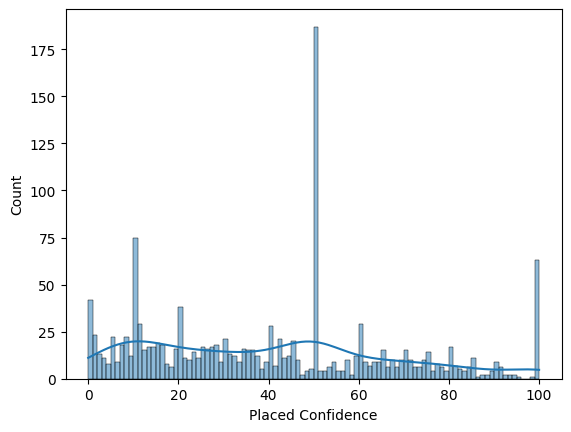

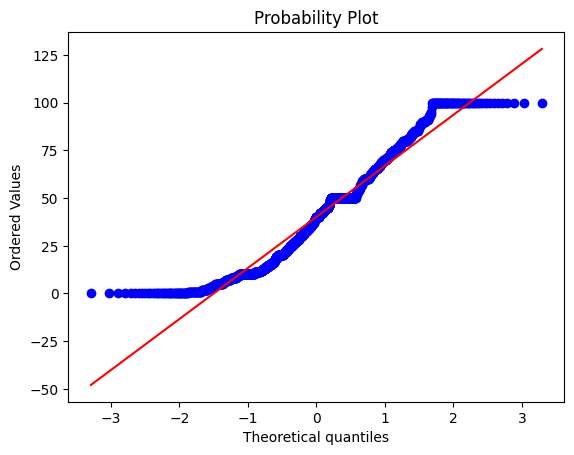

ShapiroResult(statistic=0.950636892743849, pvalue=3.420140652041956e-21)

In [45]:

# test normal distribution
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
sns.histplot(df['Placed Confidence'], bins=100, kde=True)
plt.show()
stats.probplot(df['Placed Confidence'], dist="norm", plot=plt)
plt.show()
stats.shapiro(df['Placed Confidence'])

Confidence threshold ≈ 0.00


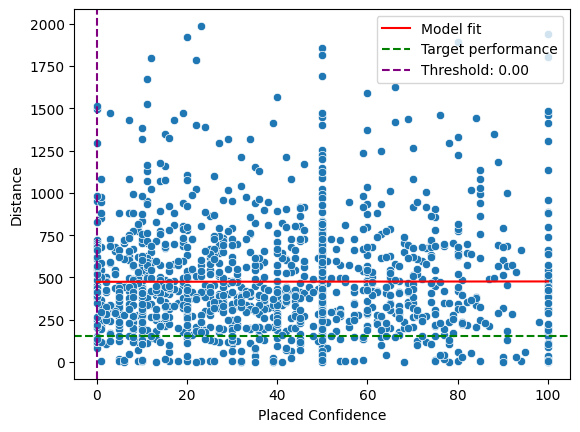

Correlation: 0.00, p-value: 0.9462


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Fit regression model
X = df['Placed Confidence'].values.reshape(-1, 1)
y = df['Distance'].values
reg = LinearRegression().fit(X, y)

# Predict distance across the confidence range
conf_range = np.linspace(df['Placed Confidence'].min(), df['Placed Confidence'].max(), 100).reshape(-1, 1)
pred_dist = reg.predict(conf_range)

# Choose a "good enough" performance threshold
# e.g., mean - 1 standard deviation (or an empirically defined acceptable distance)
acceptable_distance = y.mean() - y.std()

# Find the confidence level where predicted distance crosses that threshold
conf_threshold = conf_range[np.argmin(np.abs(pred_dist - acceptable_distance))][0]
print(f"Confidence threshold ≈ {conf_threshold:.2f}")

# Plot
sns.scatterplot(x='Placed Confidence', y='Distance', data=df)
plt.plot(conf_range, pred_dist, color='red', label='Model fit')
plt.axhline(acceptable_distance, color='green', linestyle='--', label='Target performance')
plt.axvline(conf_threshold, color='purple', linestyle='--', label=f'Threshold: {conf_threshold:.2f}')
plt.legend()
plt.show()

# print correlation and significance
spatial_corr, spatial_p_value = stats.pearsonr(df['Placed Confidence'], df['Distance'])
print(f"Correlation: {spatial_corr:.2f}, p-value: {spatial_p_value:.4f}")

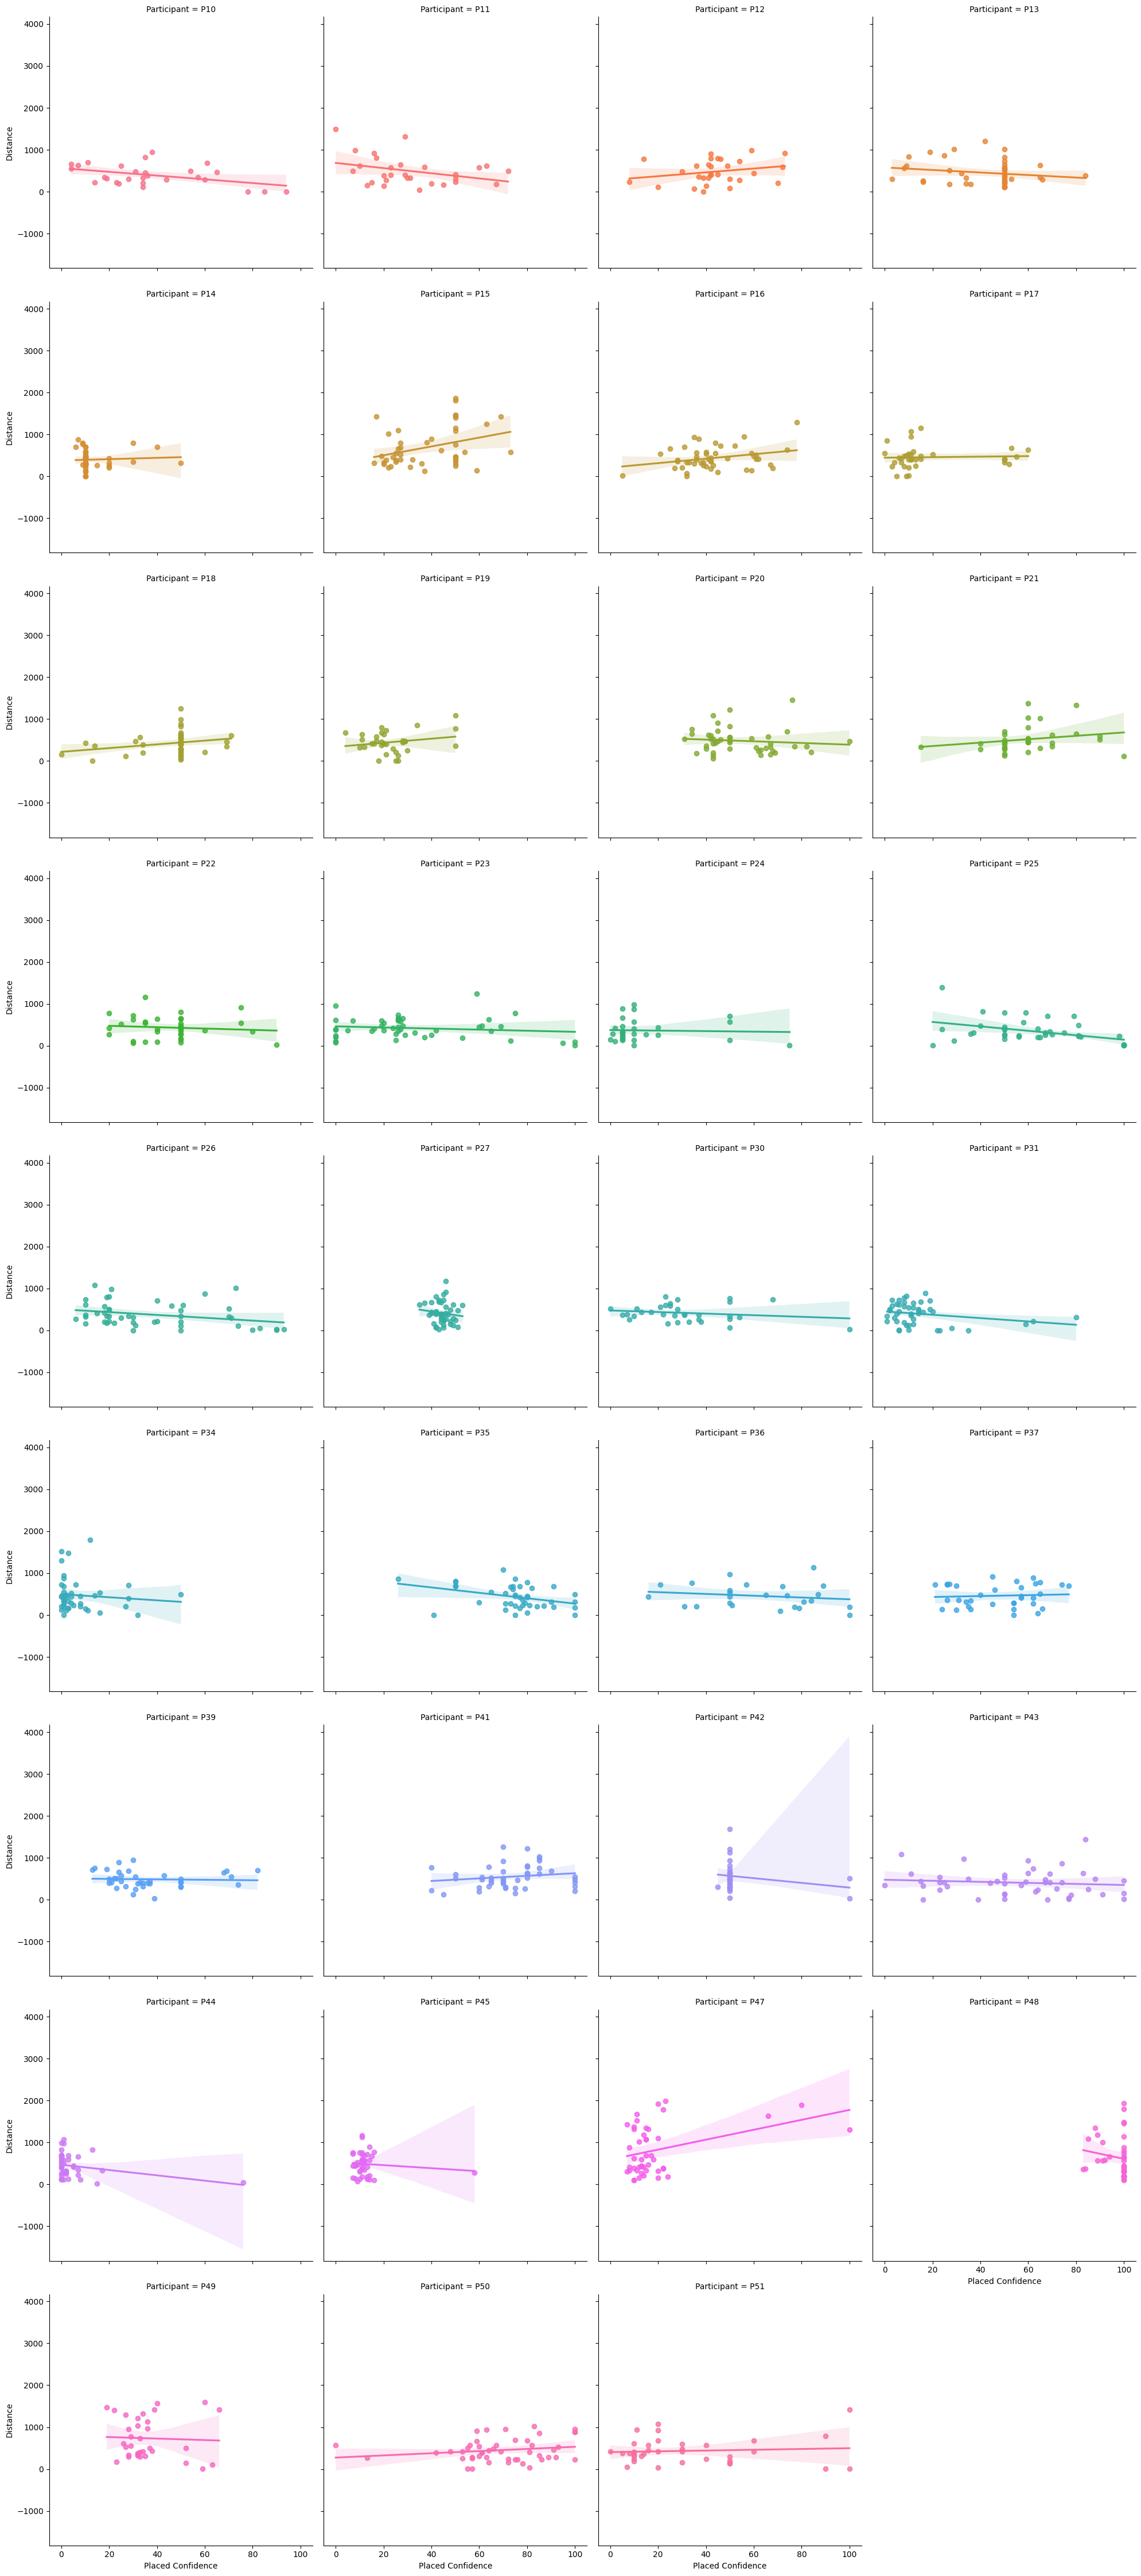

In [47]:
import seaborn as sns
sns.lmplot(x='Placed Confidence', y='Distance', data=df, hue='Participant', col='Participant', col_wrap=4)
plt.show()

In [48]:
# Compute within-subject correlations
per_participant_spatial_corrs = (
    df.groupby('Participant')
      .apply(lambda x: x['Placed Confidence'].corr(x['Distance']))
)

# One-sample t-test: are mean correlations significantly > 0 ?
per_participant_spatial_t, per_participant_spatial_p = ttest_1samp(per_participant_spatial_corrs, 0)
print(f"Mean r = {per_participant_spatial_corrs.mean():.3f}, t = {per_participant_spatial_t:.2f}, p = {per_participant_spatial_p:.4e}")

Mean r = -0.049, t = -1.30, p = 2.0350e-01


/tmp/ipykernel_4018486/1968254830.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('Participant')


# Temporal

## Confidence

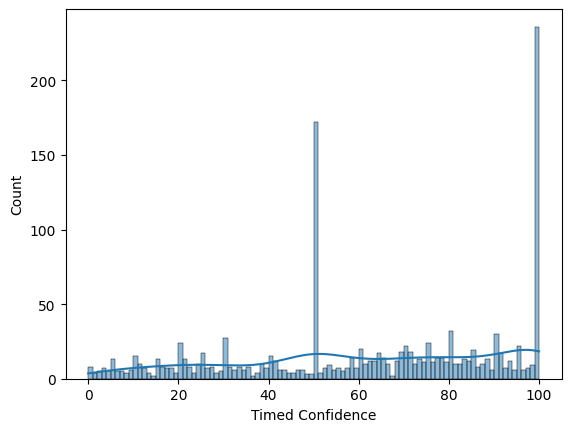

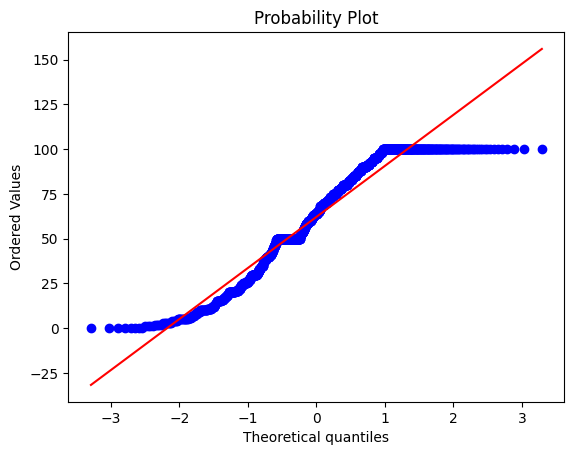

ShapiroResult(statistic=0.933748106275592, pvalue=2.3828562361272103e-24)

In [49]:
sns.histplot(df['Timed Confidence'], bins=100, kde=True)
plt.show()
# test normal distribution
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
stats.probplot(df['Timed Confidence'], dist="norm", plot=plt)
plt.show()
stats.shapiro(df['Timed Confidence'])

In [50]:
# Compute the difference (error)
df['Timed Error'] = np.abs(df['Timed'] - df['True Time'])
df['Timed Correct'] = df['Timed'] == df['True Time']

### Overall

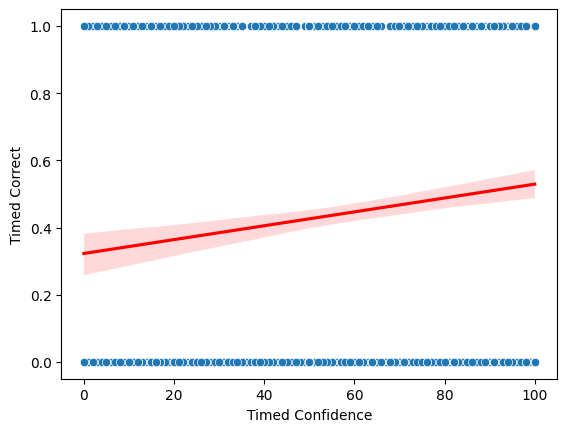

R2: 0.015
Pearsons correlation: 0.122, p-value: 0.0000


In [51]:
# plot
sns.scatterplot(x='Timed Confidence', y='Timed Correct', data=df)
# fit regression line
sns.regplot(x='Timed Confidence', y='Timed Correct', data=df, scatter=False, color='red')
# show r2
plt.show()
# calculate r2
from sklearn.linear_model import LinearRegression
X = df['Timed Confidence'].values.reshape(-1, 1)
y = df['Timed Correct'].values
reg = LinearRegression().fit(X, y)
r2 = reg.score(X, y)
print('R2: %.3f' % r2)
# Pearson correlation
from scipy.stats import pearsonr
temporal_correct_corr, temporal_correct_p = pearsonr(df['Timed Confidence'], df['Timed Correct'])
print('Pearsons correlation: %.3f, p-value: %.4f' % (temporal_correct_corr, temporal_correct_p))

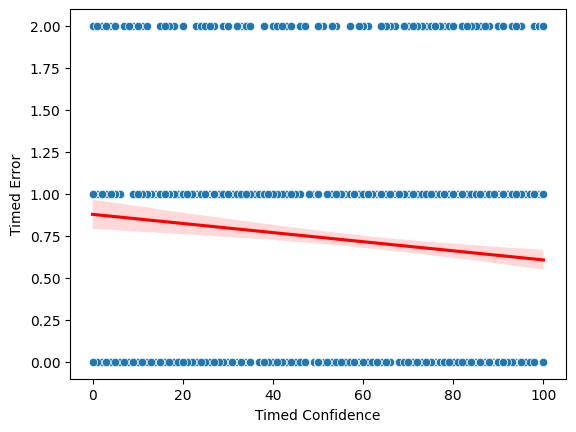

R2: 0.012
Pearsons correlation: -0.110, p-value: 0.0000


In [52]:
# plot
sns.scatterplot(x='Timed Confidence', y='Timed Error', data=df)
# fit regression line
sns.regplot(x='Timed Confidence', y='Timed Error', data=df, scatter=False, color='red')
# show r2
plt.show()
# calculate r2
from sklearn.linear_model import LinearRegression
X = df['Timed Confidence'].values.reshape(-1, 1)
y = df['Timed Error'].values
reg = LinearRegression().fit(X, y)
r2 = reg.score(X, y)
print('R2: %.3f' % r2)
# Pearson correlation
from scipy.stats import pearsonr
temporal_error_corr, temporal_error_p = pearsonr(df['Timed Confidence'], df['Timed Error'])
print('Pearsons correlation: %.3f, p-value: %.4f' % (temporal_error_corr, temporal_error_p))

### Per Patient

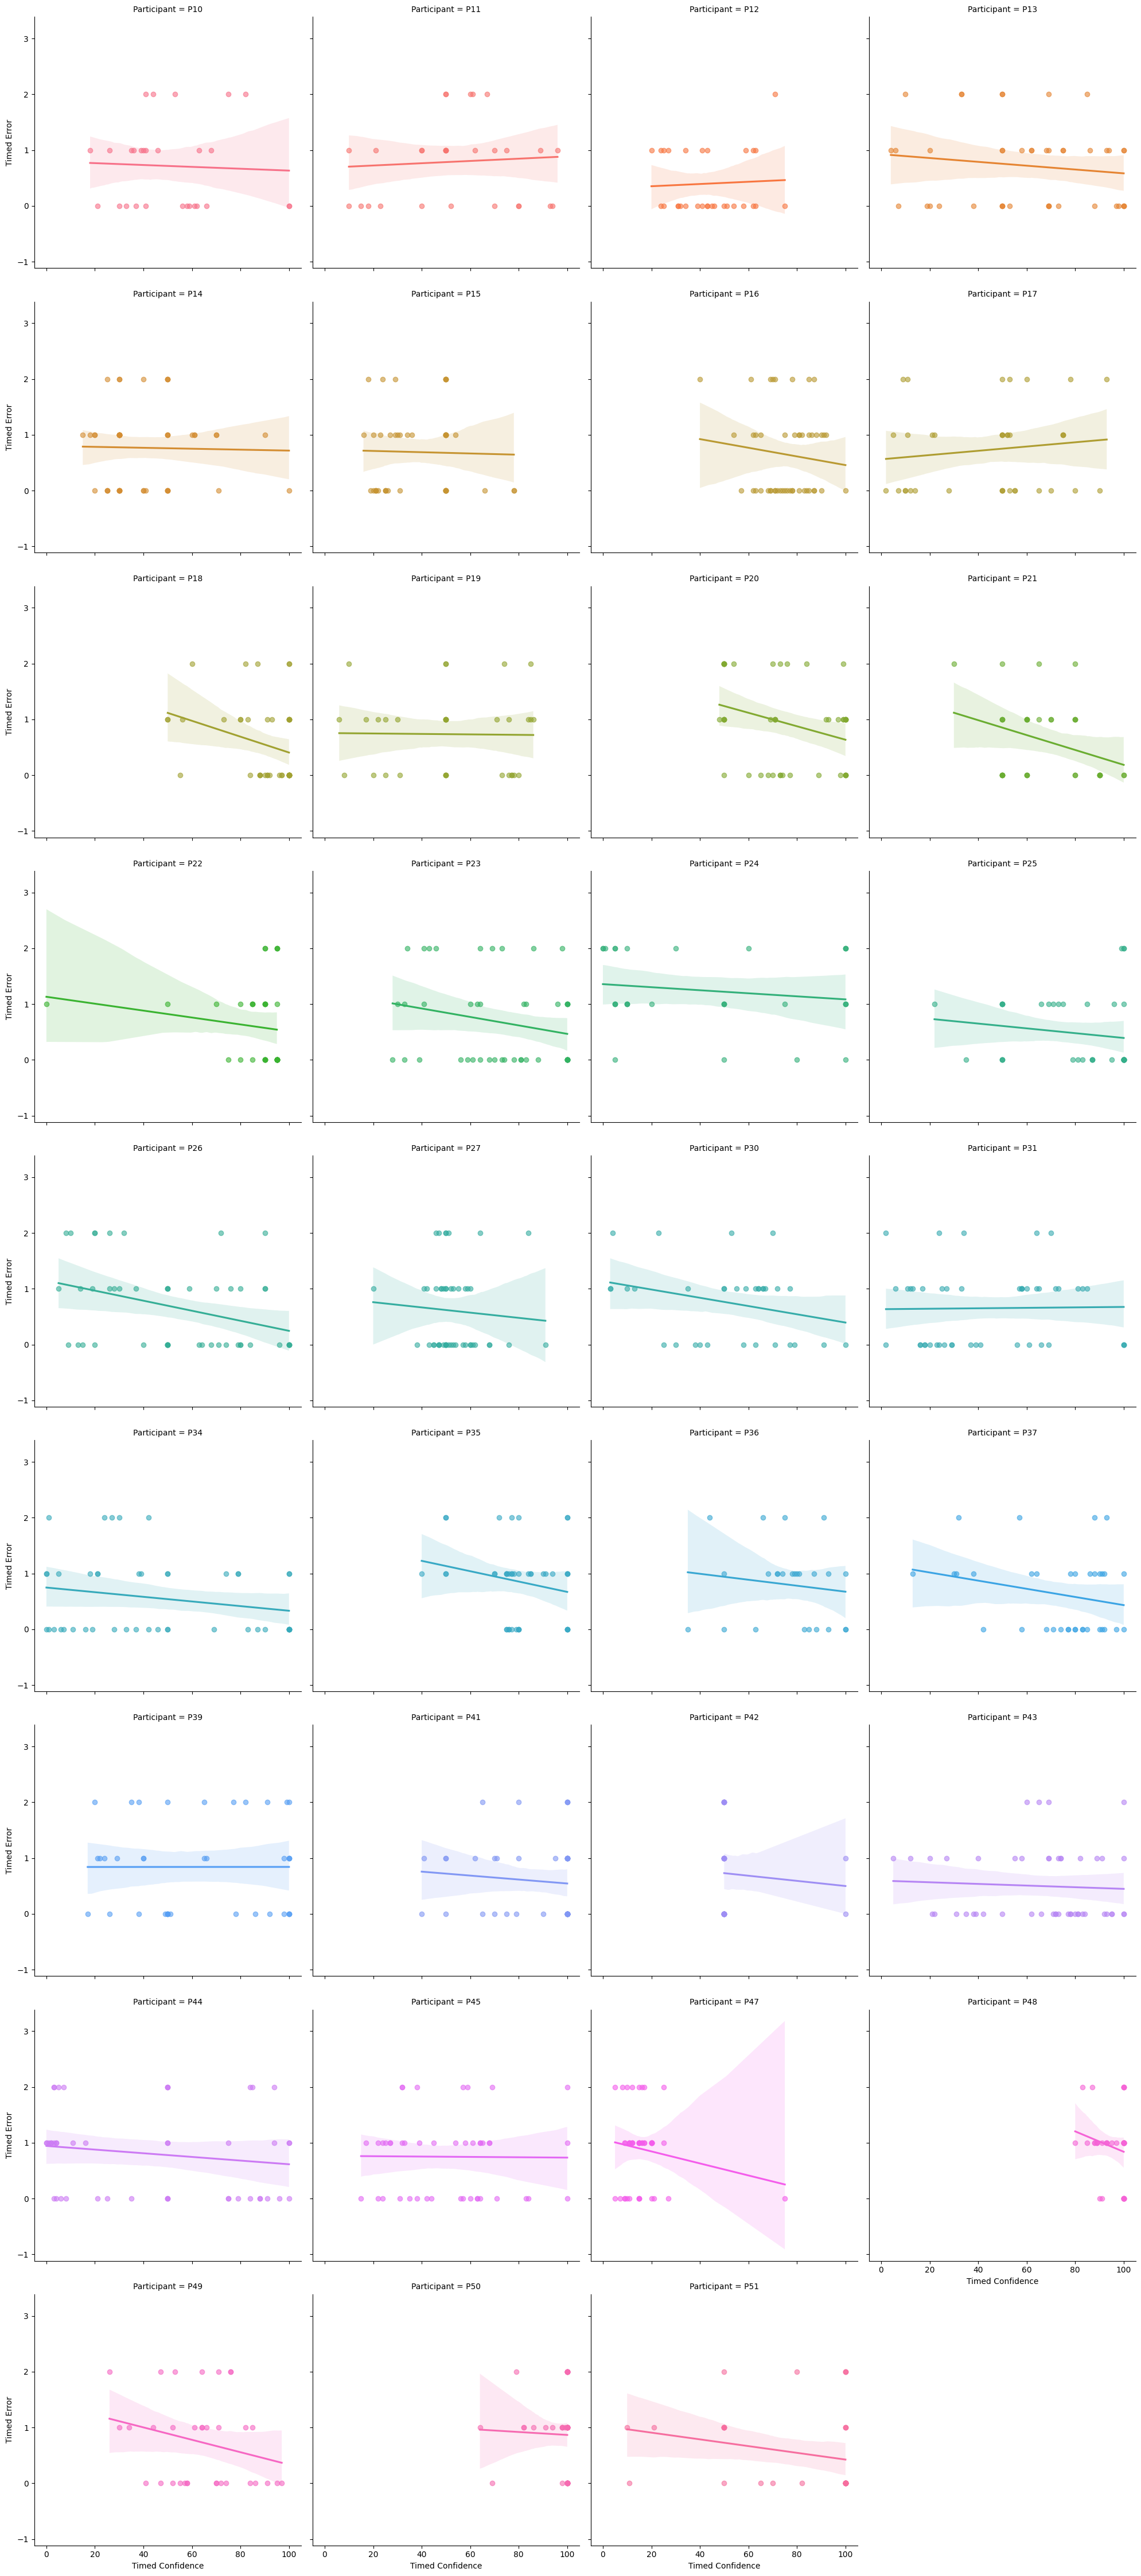

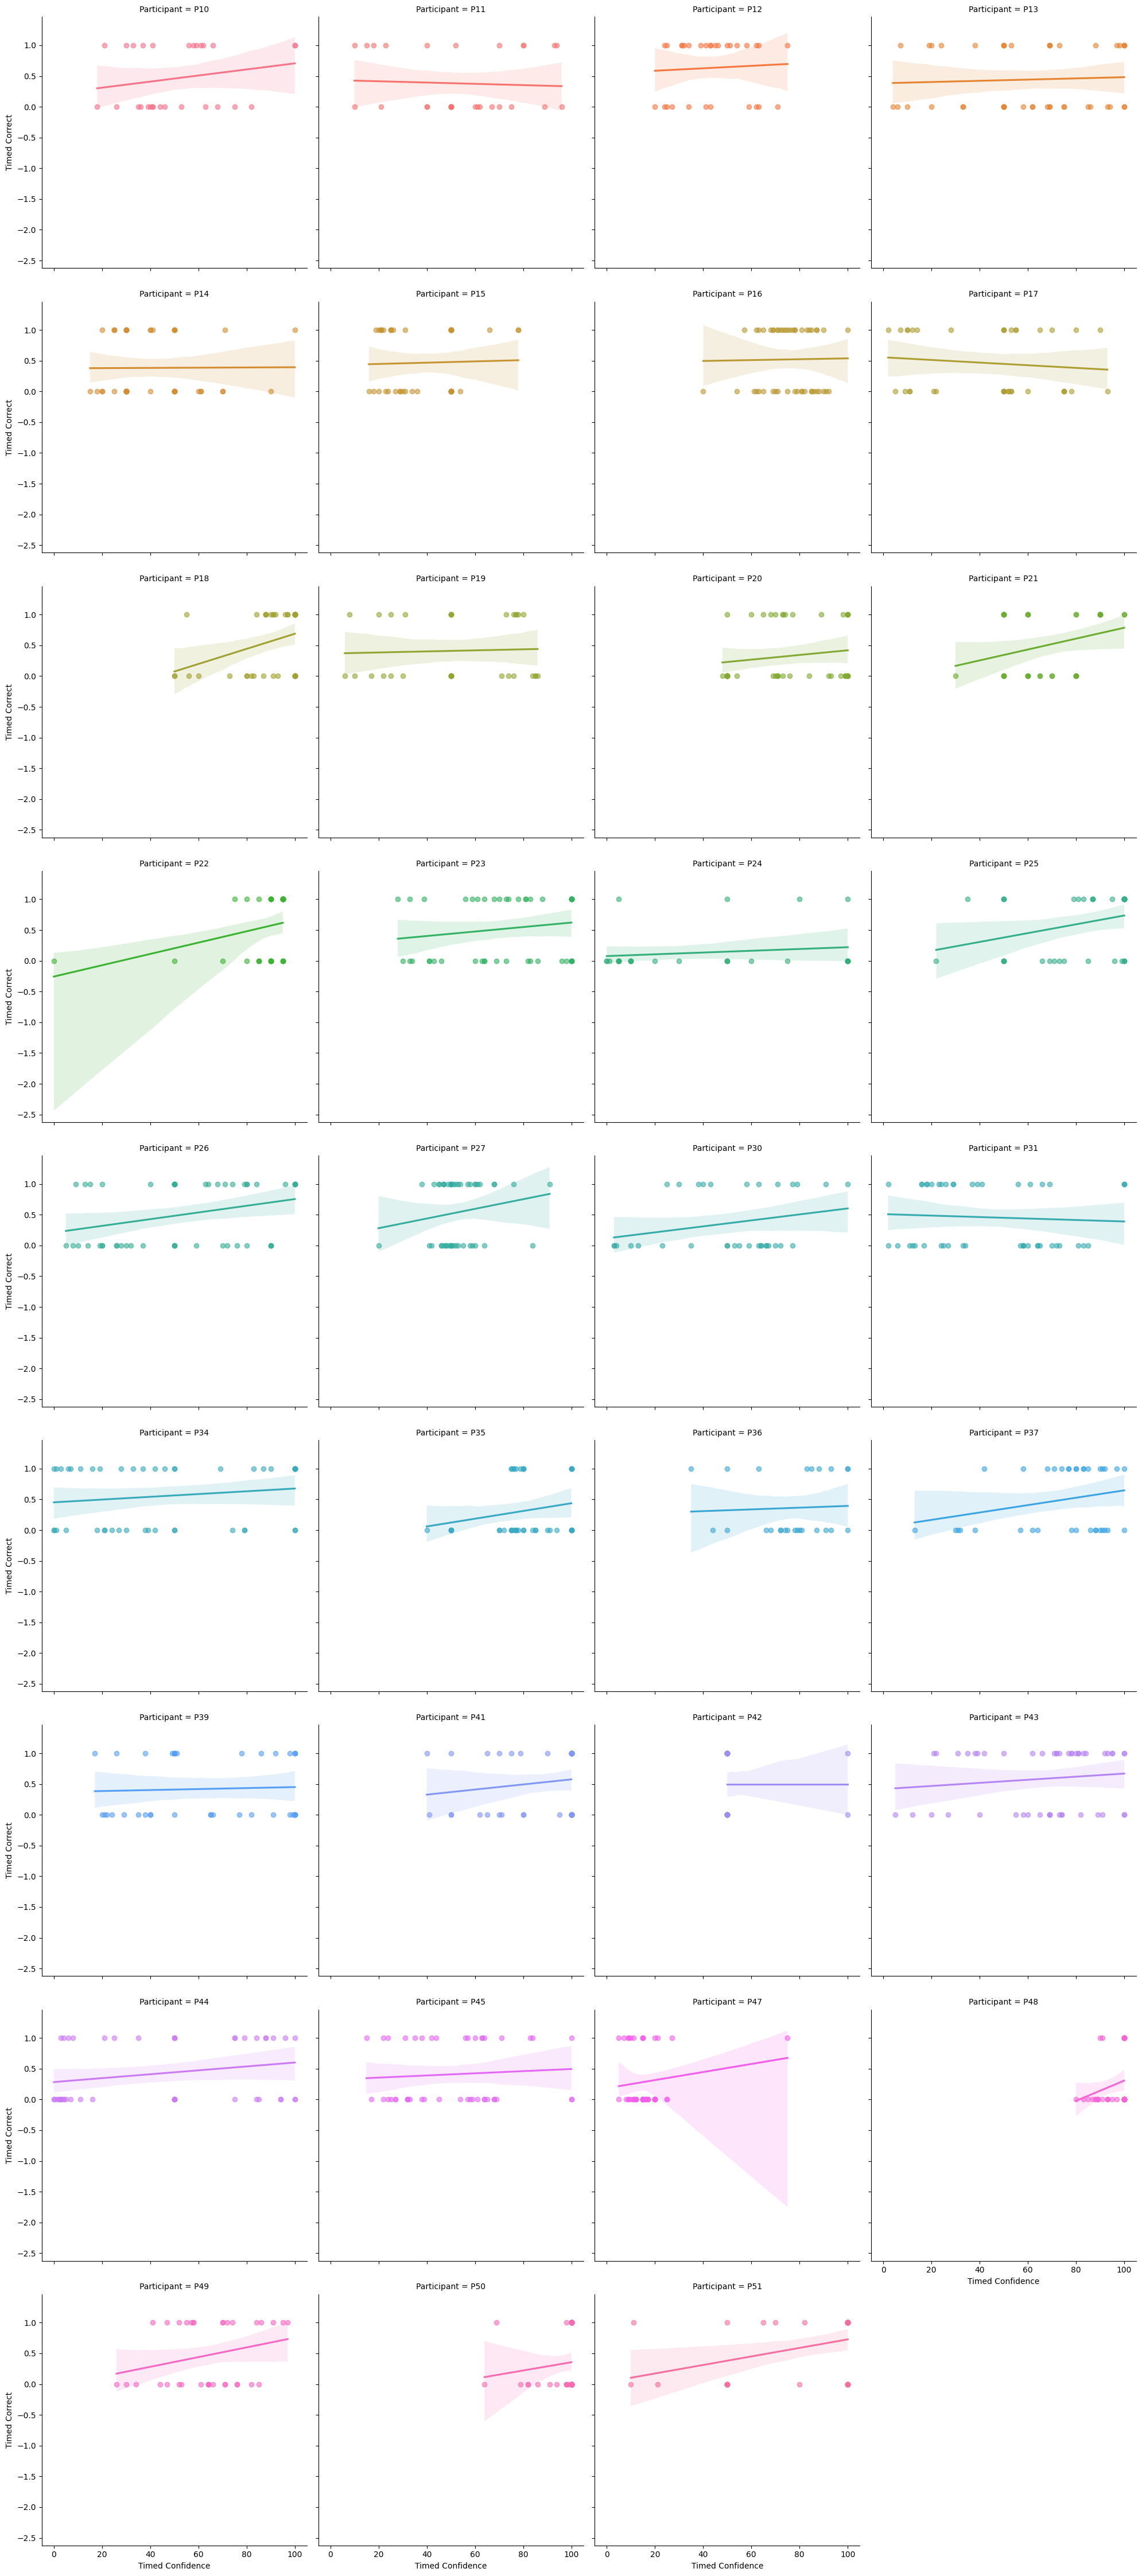

In [53]:

# Plot per participant
sns.lmplot(
    x='Timed Confidence',
    y='Timed Error',
    data=df,
    hue='Participant',
    col='Participant',
    col_wrap=4,
    scatter_kws={'alpha':0.6}
)
plt.show()
# Plot per participant
sns.lmplot(
    x='Timed Confidence',
    y='Timed Correct',
    data=df,
    hue='Participant',
    col='Participant',
    col_wrap=4,
    scatter_kws={'alpha':0.6}
)
plt.show()

In [54]:
# Compute within-subject correlations
per_participant_temporal_correct_corrs = (
    df.groupby('Participant')
      .apply(lambda x: x['Timed Confidence'].corr(x['Timed Correct']))
)

# One-sample t-test: are mean correlations significantly > 0 ?
per_participant_temporal_t, per_participant_temporal_p = ttest_1samp(per_participant_temporal_correct_corrs, 0)
print(f"Mean r = {per_participant_temporal_correct_corrs.mean():.3f}, t = {per_participant_temporal_t:.2f}, p = {per_participant_temporal_p:.4e}")

Mean r = 0.150, t = 6.87, p = 6.4806e-08


/tmp/ipykernel_4018486/3429148399.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('Participant')


In [55]:
# Compute within-subject correlations
per_participant_temporal_error_corrs = (
    df.groupby('Participant')
      .apply(lambda x: x['Timed Confidence'].corr(x['Timed Error']))
)
# One-sample t-test: are mean correlations significantly > 0 ?
per_participant_temporal_t, per_participant_temporal_p = ttest_1samp(per_participant_temporal_error_corrs, 0)
print(f"Mean r = {per_participant_temporal_error_corrs.mean():.3f}, t = {per_participant_temporal_t:.2f}, p = {per_participant_temporal_p:.4e}")

Mean r = -0.128, t = -6.20, p = 4.8071e-07


/tmp/ipykernel_4018486/808337849.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('Participant')


# Correlation

## Confidence

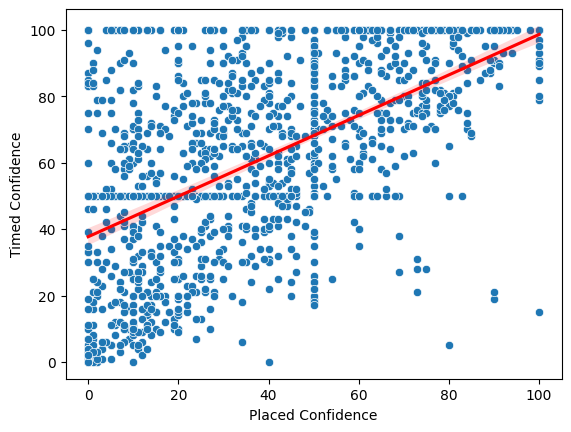

R2: 0.322
Pearsons correlation: 0.567, p-value: 0.0000


In [56]:
# study correlation between placed confidence and timed confidence
# plot
sns.scatterplot(x='Placed Confidence', y='Timed Confidence', data=df)
# fit regression line
sns.regplot(x='Placed Confidence', y='Timed Confidence', data=df, scatter=False, color='red')
# show r2   
plt.show()
# calculate r2
from sklearn.linear_model import LinearRegression
X = df['Placed Confidence'].values.reshape(-1, 1)
y = df['Timed Confidence'].values
reg = LinearRegression().fit(X, y)
r2 = reg.score(X, y)
print('R2: %.3f' % r2)
# Pearson correlation
from scipy.stats import pearsonr
inter_corr, inter_p = pearsonr(df['Placed Confidence'], df['Timed Confidence'])
print('Pearsons correlation: %.3f, p-value: %.4f' % (inter_corr, inter_p))

## Two variable Normal Distribution ? 

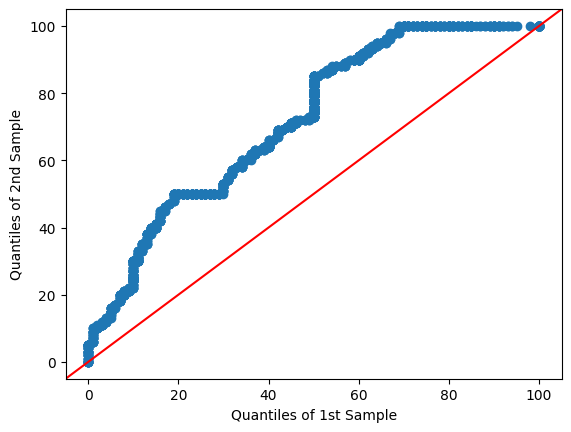

In [57]:
# study if two variables are normally distributed
sm.qqplot_2samples(df['Placed Confidence'], df['Timed Confidence'], line='45')
plt.show()

# Conclusions

In [58]:
# Print conclusions of all findings
print("Findings Summary:")
print("--- Overall ---")
print(f"Spatial Judgment - Correlation between Placed Confidence and Distance: r = {spatial_corr:.2f}, p = {spatial_p_value:.4f}")
print(f"Temporal Judgment - Correlation between Timed Confidence and Timed Correct: r = {temporal_correct_corr:.2f}, p = {temporal_correct_p:.4f}")
print(f"Temporal Judgment - Correlation between Timed Confidence and Timed Error (days): r = {temporal_error_corr:.2f}, p = {temporal_error_p:.4f}")
print(f"Inter-Domain - Correlation between Placed Confidence and Timed Confidence: r = {inter_corr:.2f}, p = {inter_p:.4f}")    

print("--- Per Participant ---")
print(f"Spatial Judgment - Mean within-participant correlation: r = {per_participant_spatial_corrs.mean():.3f}, t = {per_participant_spatial_t:.2f}, p = {per_participant_spatial_p:.4e}")
print(f"Temporal Judgment (Correct) - Mean within-participant correlation: r = {per_participant_temporal_correct_corrs.mean():.3f}, t = {per_participant_temporal_t:.2f}, p = {per_participant_temporal_p:.4e}")
print(f"Temporal Judgment (Error) - Mean within-participant correlation: r = {per_participant_temporal_error_corrs.mean():.3f}, t = {per_participant_temporal_t:.2f}, p = {per_participant_temporal_p:.4e}")    


Findings Summary:
--- Overall ---
Spatial Judgment - Correlation between Placed Confidence and Distance: r = 0.00, p = 0.9462
Temporal Judgment - Correlation between Timed Confidence and Timed Correct: r = 0.12, p = 0.0000
Temporal Judgment - Correlation between Timed Confidence and Timed Error (days): r = -0.11, p = 0.0000
Inter-Domain - Correlation between Placed Confidence and Timed Confidence: r = 0.57, p = 0.0000
--- Per Participant ---
Spatial Judgment - Mean within-participant correlation: r = -0.049, t = -1.30, p = 2.0350e-01
Temporal Judgment (Correct) - Mean within-participant correlation: r = 0.150, t = -6.20, p = 4.8071e-07
Temporal Judgment (Error) - Mean within-participant correlation: r = -0.128, t = -6.20, p = 4.8071e-07


# Per Timed Answers

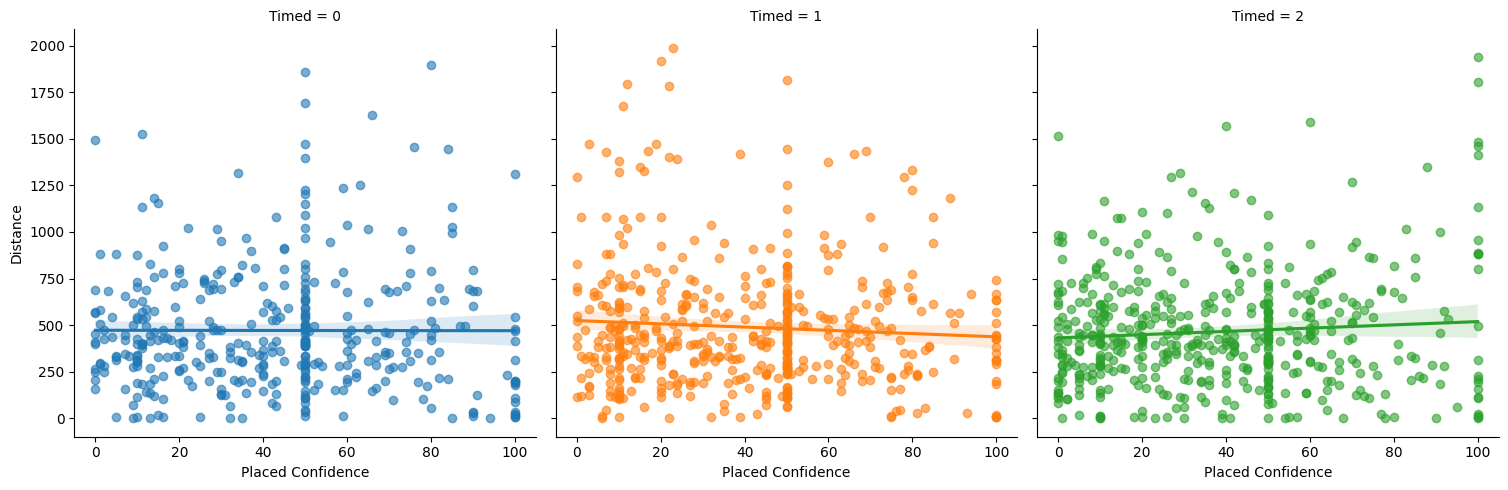

In [59]:
sns.lmplot(
    x='Placed Confidence',
    y='Distance',
    data=df,
    hue='Timed',
    col='Timed',
    col_wrap=4,
    scatter_kws={'alpha':0.6}
)

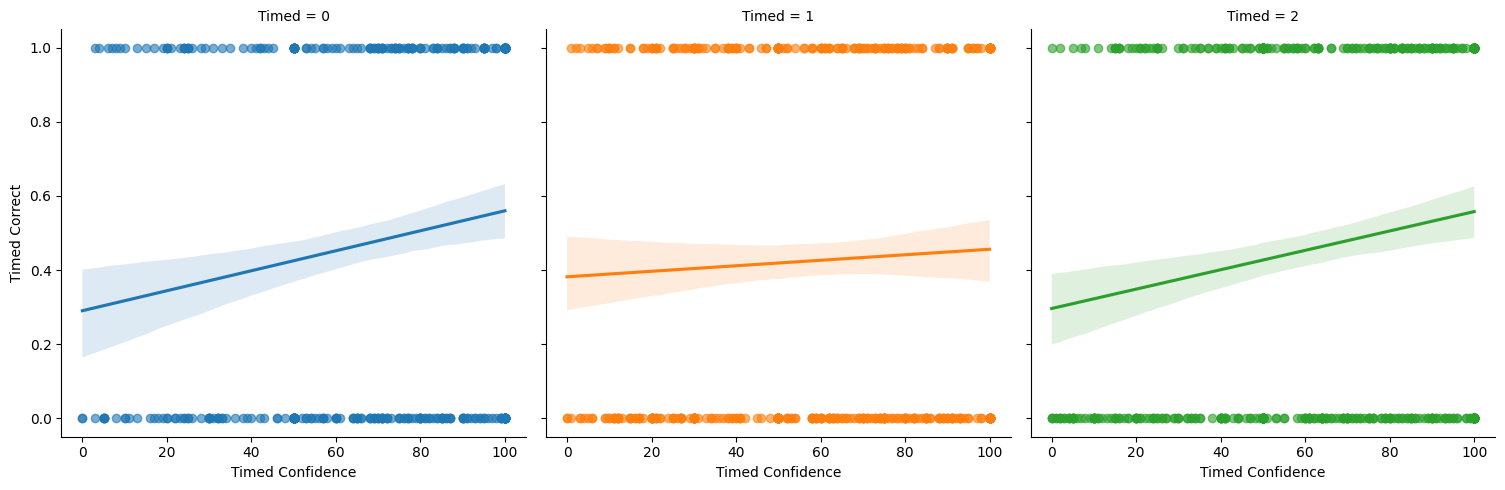

In [60]:
sns.lmplot(
    x='Timed Confidence',
    y='Timed Correct',
    data=df,
    hue='Timed',
    col='Timed',
    col_wrap=4,
    scatter_kws={'alpha':0.6}
)